# Model Analysis Notebook

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use(hep.style.ATLAS)

sys.path.append(os.path.abspath('..'))
from ringer_zero.torch import model_inference  # noqa: E402

%matplotlib inline

In [2]:
model_path = Path("/home/pedro/cern/ringer-zero/results/vkan")
dataset_dir = Path("/home/pedro/cern/data/mc21_isabela_qt_no_restriction")

In [3]:
model_df = model_inference(model_path, dataset_dir)

model_df.head()

100%|██████████| 25/25 [02:04<00:00,  4.96s/it]


,id,output,logits
0,1051262,0.000168,-8.693989
1,1052118,0.000038,-10.187846
2,1050645,0.000044,-10.021181
3,1050499,0.000105,-9.160910
4,1133514,0.000495,-7.610495


In [4]:
data_df = pd.read_parquet(dataset_dir / "electron_ringer.parquet", columns=["id", "EventInfoContainer.avgmu"])
fold_df = pd.read_parquet(dataset_dir / "standard_binning_kfold.parquet", columns=["id", "kfold", "label"])
merged_df = pd.merge(model_df, data_df, on="id")
merged_df = pd.merge(merged_df, fold_df, on="id")

merged_df.head()

,id,output,logits,EventInfoContainer.avgmu,kfold,label
0,1051262,0.000168,-8.693989,63.500000,3,False
1,1052118,0.000038,-10.187846,25.500000,0,False
2,1050645,0.000044,-10.021181,52.499996,4,False
3,1050499,0.000105,-9.160910,51.500000,0,False
4,1133514,0.000495,-7.610495,24.500000,1,False


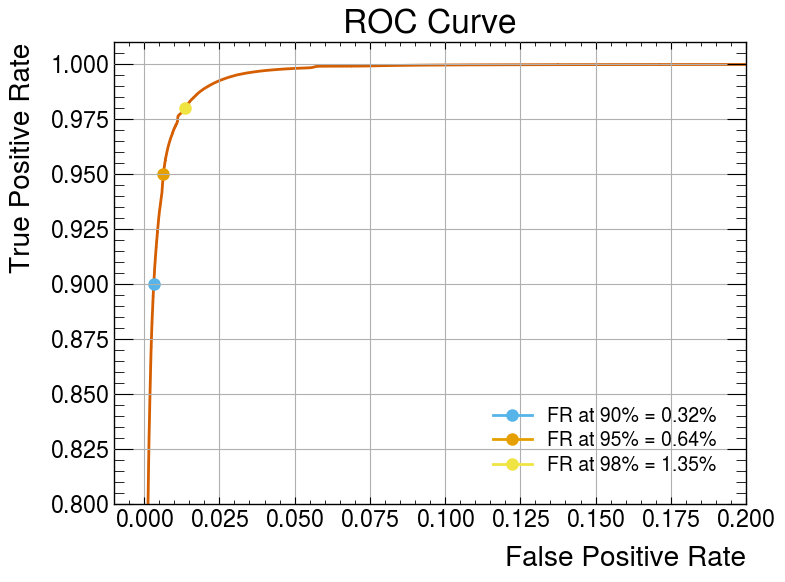

In [9]:
fpr, tpr, thresholds = roc_curve(merged_df["label"], merged_df["output"])
fig, ax = plt.subplots()
ax.plot(fpr, tpr)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")

ax.set_xlim(-.01, .2)
ax.set_ylim(.8, 1.01)

tpr_thresholds = [0.9, 0.95, 0.98]
for tpr_threshold in tpr_thresholds:
    idx = np.argmin(np.abs(tpr - tpr_threshold))
    ax.plot(fpr[idx], tpr[idx], marker="o", label=f"FR at {tpr_threshold:.0%} = {fpr[idx]:.2%}")
ax.legend()

ax.grid()
plt.show()